In [ ]:
import re
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analysis_util import project_root

ROOT_DIR = project_root()

In [2]:
###
### Create the dataframe with what you require for analysis.
###


df_criminal = pd.read_csv(ROOT_DIR / "data/model_grades/criminal_law/criminal_law_ground_truth_and_model_output.csv")
df_public = pd.read_csv(ROOT_DIR / "data/model_grades/public_law/public_law_ground_truth_and_model_output.csv")


# ------------------------------------------------------------
# config
# ------------------------------------------------------------

###
### Ensemble models. Open-L and Open-S.
###

# Open-L (large models)
model_large = [
    'mistral-large-2512',
    'deepseek-v3.1-terminus',
    'qwen3-235b-a22b-thinking-2507'
]

# Open-S (smaller models)
model_small = [
    'qwen3-next-80b-a3b-thinking',
    'gpt-oss-20b',
    'qwen3-30b-a3b-thinking-2507'
]


best_llm = [
    'gpt-5-2025-08-07',
    'gemini-2.5-pro',
]


# gold_col = "points"
prefix = "prompt_v5_ts_ext_rubric_model"
suffix = "__extracted_element"
iters = (1, 2, 3)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def build_iter_cols(df, models, prefix, suffix, iters=(1, 2, 3)):
    iter_cols = {i: [] for i in iters}
    for m in models:
        cols = df.filter(regex=rf"{prefix}.*{re.escape(m)}.*{suffix}$").columns
        for i in iters:
            c = [c for c in cols if f"__i{i}__" in c]
            if len(c) != 1:
                raise ValueError(
                    f"Expected exactly 1 column for model={m}, i{i}; found {len(c)}.\n"
                    f"Matched columns: {list(cols)}"
                )
            iter_cols[i].append(c[0])
    return iter_cols


def ensemble_raters(
    df,
    iter_cols,
    models,
    agg="median",
    iters=(1, 2, 3),
    round_result=None,
    group_suffix=None,
):
    agg = agg.lower()
    allowed = {"median", "min", "max", "mean", "mode"}
    if agg not in allowed:
        raise ValueError(f"agg must be one of {sorted(allowed)}")

    if round_result is None:
        n_raters = len(models)
        round_result = (agg == "mean") or (agg == "median" and n_raters % 2 == 0)

    rater_df = pd.DataFrame(index=df.index)
    models_tag = "__".join(models)

    for i in iters:
        vals = df[iter_cols[i]].apply(pd.to_numeric, errors="coerce")

        if agg == "median":
            s = vals.median(axis=1)
        elif agg == "min":
            s = vals.min(axis=1)
        elif agg == "max":
            s = vals.max(axis=1)
        elif agg == "mean":
            s = vals.mean(axis=1)
        elif agg == "mode":
            s = vals.mode(axis=1)[0]

        if round_result:
            s = s.round()

        col_name = f"{agg}__{models_tag}__i{i}"
        if group_suffix is not None:
            col_name = f"{col_name}__{group_suffix}"

        rater_df[col_name] = s.astype("Int64")

    return rater_df


def extract_single_model_runs(df, model, prefix, suffix, iters=(1, 2, 3), group_suffix=None):
    """
    Keep original model name in output columns.
    Add group suffix only where applicable.
    """
    iter_cols = build_iter_cols(df, [model], prefix, suffix, iters=iters)
    out = pd.DataFrame(index=df.index)

    for i in iters:
        col = iter_cols[i][0]
        s = pd.to_numeric(df[col], errors="coerce")
        if s.dropna().mod(1).eq(0).all():
            s = s.astype("Int64")

        out_name = f"{model}__i{i}"
        if group_suffix is not None:
            out_name = f"{out_name}__{group_suffix}"

        out[out_name] = s

    return out


def make_master_grade_df(
    df,
    gold_col,
    dataset_name=None,
    id_col=None,
    include_member_runs=False,
):
    out = pd.DataFrame(index=df.index)

    out["row_id"] = df[id_col].values if id_col is not None else df.index

    if dataset_name is not None:
        out["dataset"] = dataset_name

    if gold_col not in df.columns:
        raise ValueError(f"gold_col='{gold_col}' not found in dataframe")

    gold = pd.to_numeric(df[gold_col], errors="coerce")
    if gold.dropna().mod(1).eq(0).all():
        gold = gold.astype("Int64")

    # store under a common output name
    out["gold_score"] = gold

    # NOW: extract ALL models listed in best_llm
    # (currently GPT-5 + Gemini 2.5 Pro)
    for model in best_llm:
        single_model_df = extract_single_model_runs(
            df=df,
            model=model,
            prefix=prefix,
            suffix=suffix,
            iters=iters,
            group_suffix=None,
        )
        out = pd.concat([out, single_model_df], axis=1)
    # =============================================================

    # Open-L ensemble
    iter_cols_large = build_iter_cols(df, model_large, prefix, suffix, iters=iters)
    open_l_min = ensemble_raters(
        df, iter_cols_large, model_large,
        agg="min", iters=iters, group_suffix="open_large"
    )
    open_l_median = ensemble_raters(
        df, iter_cols_large, model_large,
        agg="median", iters=iters, group_suffix="open_large"
    )
    out = pd.concat([out, open_l_min, open_l_median], axis=1)

    # Open-S ensemble
    iter_cols_small = build_iter_cols(df, model_small, prefix, suffix, iters=iters)
    open_s_min = ensemble_raters(
        df, iter_cols_small, model_small,
        agg="min", iters=iters, group_suffix="open_small"
    )
    open_s_median = ensemble_raters(
        df, iter_cols_small, model_small,
        agg="median", iters=iters, group_suffix="open_small"
    )
    out = pd.concat([out, open_s_min, open_s_median], axis=1)

    # Optional: raw member runs with suffixes
    if include_member_runs:
        for model in model_large:
            member_df = extract_single_model_runs(
                df=df,
                model=model,
                prefix=prefix,
                suffix=suffix,
                iters=iters,
                group_suffix="open_large",
            )
            out = pd.concat([out, member_df], axis=1)

        for model in model_small:
            member_df = extract_single_model_runs(
                df=df,
                model=model,
                prefix=prefix,
                suffix=suffix,
                iters=iters,
                group_suffix="open_small",
            )
            out = pd.concat([out, member_df], axis=1)

    return out.reset_index(drop=True)


grades_criminal = make_master_grade_df(
    df=df_criminal,
    gold_col="points",
    dataset_name="criminal",
    id_col=None,
    include_member_runs=True,
)

grades_public = make_master_grade_df(
    df=df_public,
    gold_col="MH_grade_mRPS",
    dataset_name="public",
    id_col=None,
    include_member_runs=True,
)

grades_all = pd.concat([grades_criminal, grades_public], ignore_index=True)

In [3]:
# show all columns pandas
pd.set_option("display.max_columns", None)

grades_all

,row_id,dataset,gold_score,gpt-5-2025-08-07__i1,gpt-5-2025-08-07__i2,gpt-5-2025-08-07__i3,gemini-2.5-pro__i1,gemini-2.5-pro__i2,gemini-2.5-pro__i3,min__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i1__open_large,min__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i2__open_large,min__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i3__open_large,median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i1__open_large,median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i2__open_large,median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i3__open_large,min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i1__open_small,min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i2__open_small,min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i3__open_small,median__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i1__open_small,median__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i2__open_small,median__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i3__open_small,mistral-large-2512__i1__open_large,mistral-large-2512__i2__open_large,mistral-large-2512__i3__open_large,deepseek-v3.1-terminus__i1__open_large,deepseek-v3.1-terminus__i2__open_large,deepseek-v3.1-terminus__i3__open_large,qwen3-235b-a22b-thinking-2507__i1__open_large,qwen3-235b-a22b-thinking-2507__i2__open_large,qwen3-235b-a22b-thinking-2507__i3__open_large,qwen3-next-80b-a3b-thinking__i1__open_small,qwen3-next-80b-a3b-thinking__i2__open_small,qwen3-next-80b-a3b-thinking__i3__open_small,gpt-oss-20b__i1__open_small,gpt-oss-20b__i2__open_small,gpt-oss-20b__i3__open_small,qwen3-30b-a3b-thinking-2507__i1__open_small,qwen3-30b-a3b-thinking-2507__i2__open_small,qwen3-30b-a3b-thinking-2507__i3__open_small
0,0,criminal,2,3,3,3,3,2,2,2,2,2,3,2,3,2,4,2,4,4,2,4,3,2,2,2,3,3,2,3,4,4,2,5,4,6,2,4,2
1,1,criminal,7,7,6,7,6,8,6,3,5,3,5,7,8,7,3,4,8,9,9,18,9,16,3,7,3,5,5,8,7,12,10,10,3,4,8,9,9
2,2,criminal,7,5,6,6,6,6,7,7,8,5,7,9,6,7,5,13,9,7,14,7,13,6,7,9,9,9,8,5,7,5,13,9,17,14,14,7,18
3,3,criminal,5,7,7,7,8,7,8,4,5,4,8,9,13,6,12,13,9,14,14,18,10,16,4,5,4,8,9,13,9,14,18,10,15,14,6,12,13
4,4,criminal,4,8,8,9,9,8,9,5,7,7,9,7,8,9,7,7,9,16,15,9,15,9,5,7,8,9,7,7,17,18,15,9,16,7,9,7,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,11,public,10,12,11,10,9,9,8,8,6,6,11,12,11,8,5,5,11,11,13,11,12,12,8,6,6,14,12,11,11,11,14,8,5,5,15,13,13
83,12,public,10,8,6,7,6,6,5,6,4,7,6,7,8,8,8,5,8,8,7,6,7,8,6,4,7,8,9,14,8,8,9,8,12,5,8,8,7
84,13,public,10,10,10,11,11,9,10,6,10,11,12,11,11,13,12,12,17,12,17,14,13,15,12,10,11,6,11,11,13,12,12,18,12,17,17,17,17
85,14,public,11,13,13,13,11,14,11,10,6,9,14,9,11,12,9,8,12,17,15,14,13,15,10,6,9,15,9,11,12,17,8,12,9,17,17,17,15


### Calibration plot with SD bands

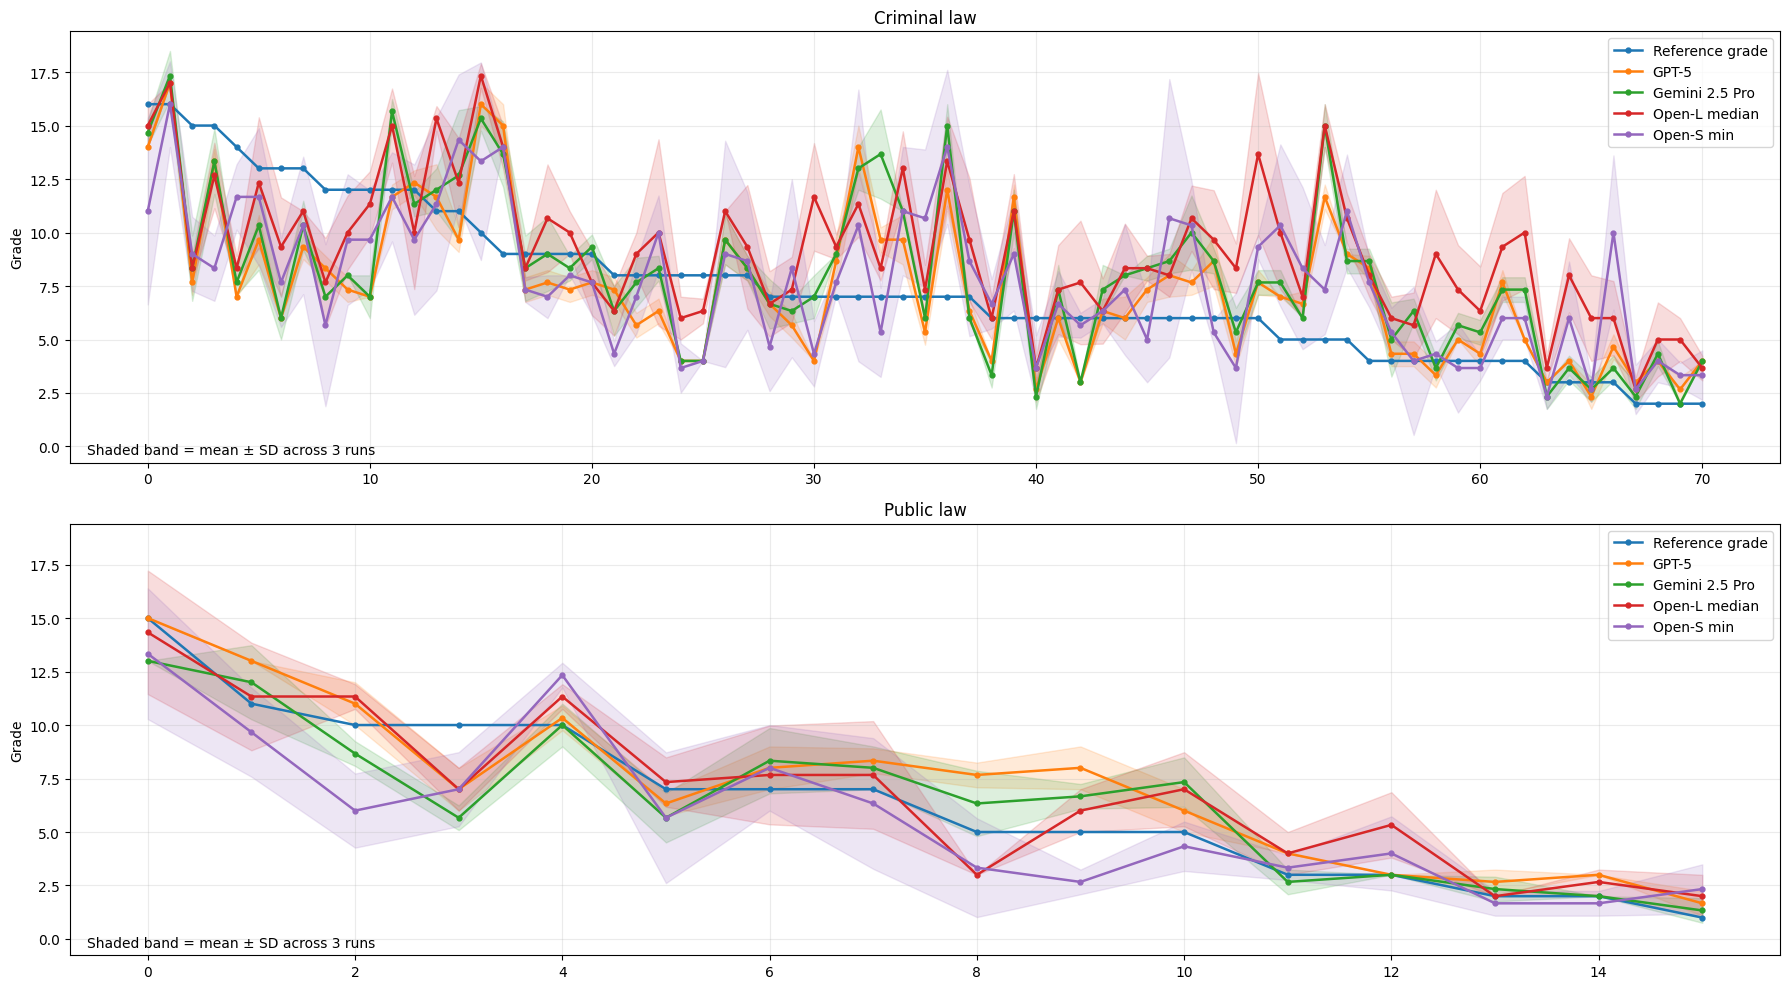

In [4]:
###
### Models I am using: open_l median, open_s min, gpt-5, gemini-2.5-pro
###


# ------------------------------------------------------------
# helpers: find iteration columns in the master dataframe
# ------------------------------------------------------------
def get_single_model_iter_cols(df, model_name, iters=(1, 2, 3)):
    """
    Matches columns like:
    gpt-5-2025-08-07__i1
    gpt-5-2025-08-07__i2
    gpt-5-2025-08-07__i3

    Also now supports:
    gemini-2.5-pro__i1
    gemini-2.5-pro__i2
    gemini-2.5-pro__i3
    """
    pattern = re.compile(rf"^{re.escape(model_name)}__i([1-9]\d*)$")
    found = {}

    for col in df.columns:
        m = pattern.match(col)
        if m:
            i = int(m.group(1))
            if i in found:
                raise ValueError(f"More than one column matched model={model_name}, i{i}")
            found[i] = col

    missing = [i for i in iters if i not in found]
    if missing:
        raise ValueError(f"Missing columns for model={model_name}, iterations={missing}")

    return [found[i] for i in iters]


def get_ensemble_iter_cols(df, agg, group_suffix, iters=(1, 2, 3)):
    """
    Matches columns like:
    min__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i1__open_large
    median__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i2__open_small
    """
    pattern = re.compile(rf"^{agg}__.*__i([1-9]\d*)__{group_suffix}$")
    found = {}

    for col in df.columns:
        m = pattern.match(col)
        if m:
            i = int(m.group(1))
            if i in found:
                raise ValueError(
                    f"More than one column matched agg={agg}, group_suffix={group_suffix}, i{i}"
                )
            found[i] = col

    missing = [i for i in iters if i not in found]
    if missing:
        raise ValueError(
            f"Missing ensemble columns for agg={agg}, group_suffix={group_suffix}, iters={missing}"
        )

    return [found[i] for i in iters]


# ------------------------------------------------------------
# add per-row mean and SD across the 3 runs
# ------------------------------------------------------------
def add_mean_sd_columns(
    df,
    gpt_model="gpt-5-2025-08-07",
    gemini_model="gemini-2.5-pro",
    iters=(1, 2, 3)
):
    out = df.copy()

    # GPT-5
    gpt_cols = get_single_model_iter_cols(out, gpt_model, iters=iters)
    gpt_vals = out[gpt_cols].apply(pd.to_numeric, errors="coerce")
    out[f"{gpt_model}__mean"] = gpt_vals.mean(axis=1)
    out[f"{gpt_model}__sd"] = gpt_vals.std(axis=1, ddof=1)

    gemini_cols = get_single_model_iter_cols(out, gemini_model, iters=iters)
    gemini_vals = out[gemini_cols].apply(pd.to_numeric, errors="coerce")
    out[f"{gemini_model}__mean"] = gemini_vals.mean(axis=1)
    out[f"{gemini_model}__sd"] = gemini_vals.std(axis=1, ddof=1)


    # Ensembles
    specs = [
        # ("min", "open_large"),
        ("median", "open_large"),
        ("min", "open_small"),
        # ("median", "open_small"),
    ]

    for agg, group_suffix in specs:
        iter_cols = get_ensemble_iter_cols(out, agg=agg, group_suffix=group_suffix, iters=iters)
        vals = out[iter_cols].apply(pd.to_numeric, errors="coerce")

        out[f"{agg}__{group_suffix}__mean"] = vals.mean(axis=1)
        out[f"{agg}__{group_suffix}__sd"] = vals.std(axis=1, ddof=1)

    return out


# ------------------------------------------------------------
# plotting
# ------------------------------------------------------------
def plot_sorted_score_profiles_with_sd_band(
    df,
    dataset_col="dataset",
    gold_col="gold_score",
    gpt_model="gpt-5-2025-08-07",
    gemini_model="gemini-2.5-pro",
    figsize=(18, 10),
    linewidth=1.8,
    marker_size=3.5,
    band_alpha=0.16,
    savepath=None,
):
    """
    For each dataset:
    - sort rows by gold score descending
    - plot gold score as line
    - plot GPT-5 mean as line with mean±SD shaded band
    - plot Gemini 2.5 Pro mean as line with mean±SD shaded band
    - plot ensemble means as lines with mean±SD shaded bands
    """


    work = add_mean_sd_columns(
        df,
        gpt_model=gpt_model,
        gemini_model=gemini_model,
    )


    dataset_order = [d for d in ["criminal", "public"] if d in set(work[dataset_col].dropna())]
    if not dataset_order:
        dataset_order = list(work[dataset_col].dropna().unique())

    if len(dataset_order) == 0:
        raise ValueError(f"No non-null values found in dataset column '{dataset_col}'")

    fig, axes = plt.subplots(
        nrows=len(dataset_order),
        ncols=1,
        figsize=figsize,
        sharex=False,
        sharey=True
    )

    if len(dataset_order) == 1:
        axes = [axes]

    # label, mean_col, sd_col
    series_specs = [
        ("GPT-5", f"{gpt_model}__mean", f"{gpt_model}__sd"),
        ("Gemini 2.5 Pro", f"{gemini_model}__mean", f"{gemini_model}__sd"),
        # ("Open-L min", "min__open_large__mean", "min__open_large__sd"),
        ("Open-L median", "median__open_large__mean", "median__open_large__sd"),
        ("Open-S min", "min__open_small__mean", "min__open_small__sd"),
        # ("Open-S median", "median__open_small__mean", "median__open_small__sd"),
    ]

    for ax, ds in zip(axes, dataset_order):
        d = work.loc[work[dataset_col] == ds].copy()

        d[gold_col] = pd.to_numeric(d[gold_col], errors="coerce")
        d = d.sort_values(by=gold_col, ascending=False, kind="mergesort").reset_index(drop=True)

        x = np.arange(len(d))

        # Gold line
        gold_y = pd.to_numeric(d[gold_col], errors="coerce").to_numpy(dtype=float)
        ax.plot(
            x,
            gold_y,
            marker="o",
            markersize=marker_size,
            linewidth=linewidth,
            label="Reference grade",
        )

        # Other model/ensemble lines with SD bands
        for label, mean_col, sd_col in series_specs:
            y = pd.to_numeric(d[mean_col], errors="coerce").to_numpy(dtype=float)
            sd = pd.to_numeric(d[sd_col], errors="coerce").fillna(0).to_numpy(dtype=float)

            line, = ax.plot(
                x,
                y,
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                label=label,
            )

            # Remove this to not show SD bands.
            ax.fill_between(
                x,
                y - sd,
                y + sd,
                alpha=band_alpha,
                color=line.get_color(),
            )

        ax.set_title(f"{ds.capitalize()} law")
        ax.set_ylabel("Grade")
        ax.grid(True, alpha=0.25)
        ax.legend()

        ax.text(
            0.01,
            0.02,
            "Shaded band = mean ± SD across 3 runs",
            transform=ax.transAxes,
        )

    # axes[-1].set_xlabel("Student answers sorted by reference grade (highest → lowest)")
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    return work



work_calibration = plot_sorted_score_profiles_with_sd_band(
    grades_all,
    dataset_col="dataset",
    gold_col="gold_score",
    gpt_model="gpt-5-2025-08-07",
    gemini_model="gemini-2.5-pro",
    figsize=(18, 10),
    linewidth=1.8,
    marker_size=3.5,
    band_alpha=0.16,
    savepath="calibration_plot.pdf",
)

### error buckt distrubtion anaylsis

Model specs for long dataframe construction: 
  GPT-5: ['gpt-5-2025-08-07__i1', 'gpt-5-2025-08-07__i2', 'gpt-5-2025-08-07__i3']
  Gemini 2.5 Pro: ['gemini-2.5-pro__i1', 'gemini-2.5-pro__i2', 'gemini-2.5-pro__i3']
  Open-L median: ['median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i1__open_large', 'median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i2__open_large', 'median__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i3__open_large']
  Open-S min: ['min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i1__open_small', 'min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i2__open_small', 'min__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i3__open_small']
Per-run metrics


,dataset,model,run,n_cases,exact_match_rate,within_pm1_rate,mae,severe_error_rate,mean_signed_error
0,criminal,GPT-5,1,71,0.126761,0.380282,2.43662,0.619718,0.014085
1,criminal,GPT-5,2,71,0.112676,0.464789,2.366197,0.535211,0.056338
2,criminal,GPT-5,3,71,0.126761,0.422535,2.380282,0.577465,-0.070423
3,criminal,Gemini 2.5 Pro,1,71,0.154930,0.422535,2.56338,0.577465,0.535211
4,criminal,Gemini 2.5 Pro,2,71,0.126761,0.380282,2.492958,0.619718,0.464789
5,criminal,Gemini 2.5 Pro,3,71,0.154930,0.380282,2.732394,0.619718,0.788732
6,criminal,Open-L median,1,71,0.084507,0.309859,3.042254,0.690141,1.915493
7,criminal,Open-L median,2,71,0.098592,0.267606,3.098592,0.732394,1.577465
8,criminal,Open-L median,3,71,0.070423,0.323944,3.084507,0.676056,1.788732
9,criminal,Open-S min,1,71,0.140845,0.408451,2.873239,0.591549,0.507042


Average metrics over runs


,dataset,model,runs,n_cases_per_run,exact_match_mean,exact_match_sd,within_pm1_mean,within_pm1_sd,mae_mean,mae_sd,severe_error_mean,severe_error_sd,mean_signed_error_mean,mean_signed_error_sd
0,criminal,GPT-5,3,71.0,0.122,0.008,0.423,0.042,2.394,0.037,0.577,0.042,0.0,0.065
1,criminal,Gemini 2.5 Pro,3,71.0,0.146,0.016,0.394,0.024,2.596,0.123,0.606,0.024,0.596,0.17
2,criminal,Open-L median,3,71.0,0.085,0.014,0.300,0.029,3.075,0.029,0.700,0.029,1.761,0.171
3,criminal,Open-S min,3,71.0,0.141,0.028,0.362,0.081,2.869,0.218,0.638,0.081,0.286,0.335
4,public,GPT-5,3,16.0,0.292,0.095,0.667,0.095,1.208,0.095,0.333,0.095,0.75,0.165
5,public,Gemini 2.5 Pro,3,16.0,0.396,0.180,0.646,0.036,1.208,0.144,0.354,0.036,0.0,0.25
6,public,Open-L median,3,16.0,0.167,0.072,0.542,0.095,1.521,0.201,0.458,0.095,0.438,0.41
7,public,Open-S min,3,16.0,0.208,0.072,0.417,0.191,1.833,0.52,0.583,0.191,-0.708,0.52


Bucket proportions averaged over runs (mean ± SD)


error_bucket,dataset,model,≤ -2,-1,0,+1,≥ +2
0,criminal,GPT-5,0.3 ± 0.029,0.127 ± 0.037,0.122 ± 0.008,0.174 ± 0.022,0.277 ± 0.016
1,criminal,Gemini 2.5 Pro,0.211 ± 0.014,0.131 ± 0.029,0.146 ± 0.016,0.117 ± 0.035,0.394 ± 0.014
2,criminal,Open-L median,0.164 ± 0.016,0.085 ± 0.0,0.085 ± 0.014,0.131 ± 0.043,0.535 ± 0.014
3,criminal,Open-S min,0.296 ± 0.086,0.113 ± 0.024,0.141 ± 0.028,0.108 ± 0.035,0.343 ± 0.008
4,public,GPT-5,0.062 ± 0.0,0.042 ± 0.036,0.292 ± 0.095,0.333 ± 0.036,0.271 ± 0.095
5,public,Gemini 2.5 Pro,0.188 ± 0.062,0.083 ± 0.095,0.396 ± 0.18,0.167 ± 0.072,0.167 ± 0.036
6,public,Open-L median,0.208 ± 0.036,0.021 ± 0.036,0.167 ± 0.072,0.354 ± 0.072,0.25 ± 0.125
7,public,Open-S min,0.375 ± 0.108,0.104 ± 0.036,0.208 ± 0.072,0.104 ± 0.13,0.208 ± 0.095


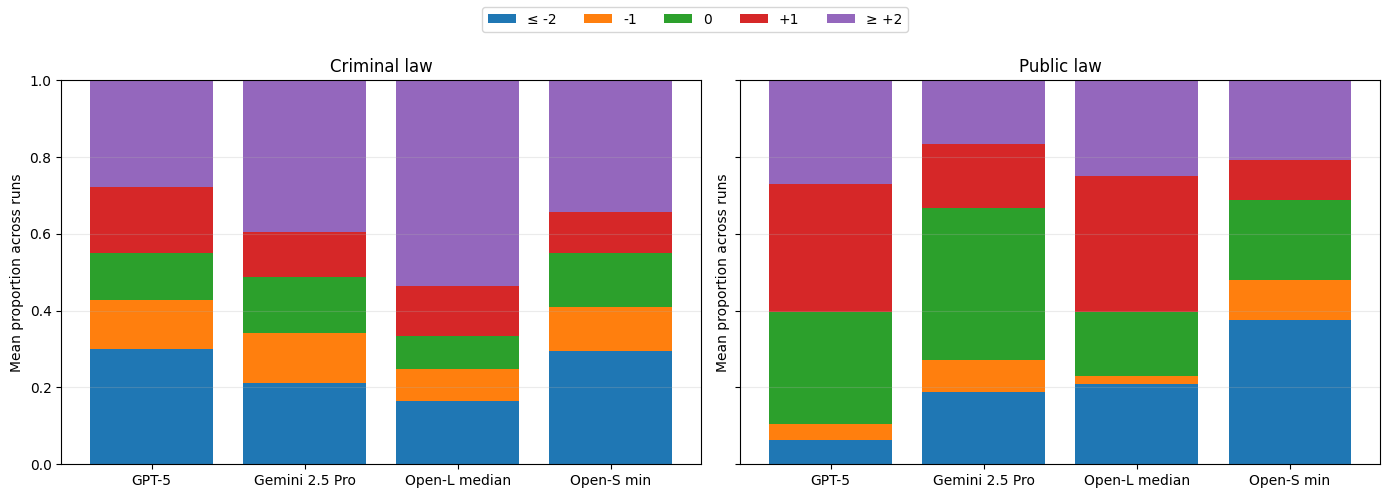

In [5]:
###
### models used: open_l median, open_s min, gpt-5, gemini-2.5-pro for public and criminal law.
###


# ------------------------------------------------------------
# helpers: find iteration columns in the master dataframe
# ------------------------------------------------------------
def get_single_model_iter_cols(df, model_name, iters=(1, 2, 3)):
    """
    Matches columns like:
    gpt-5-2025-08-07__i1
    gpt-5-2025-08-07__i2
    gpt-5-2025-08-07__i3

    Also now supports:
    gemini-2.5-pro__i1
    gemini-2.5-pro__i2
    gemini-2.5-pro__i3
    """
    pattern = re.compile(rf"^{re.escape(model_name)}__i([1-9]\d*)$")
    found = {}

    for col in df.columns:
        m = pattern.match(col)
        if m:
            i = int(m.group(1))
            if i in found:
                raise ValueError(f"More than one column matched model={model_name}, i{i}")
            found[i] = col

    missing = [i for i in iters if i not in found]
    if missing:
        raise ValueError(f"Missing columns for model={model_name}, iterations={missing}")

    return [found[i] for i in iters]


def get_ensemble_iter_cols(df, agg, group_suffix, iters=(1, 2, 3)):
    """
    Matches columns like:
    min__mistral-large-2512__deepseek-v3.1-terminus__qwen3-235b-a22b-thinking-2507__i1__open_large
    median__qwen3-next-80b-a3b-thinking__gpt-oss-20b__qwen3-30b-a3b-thinking-2507__i2__open_small
    """
    pattern = re.compile(rf"^{agg}__.*__i([1-9]\d*)__{group_suffix}$")
    found = {}

    for col in df.columns:
        m = pattern.match(col)
        if m:
            i = int(m.group(1))
            if i in found:
                raise ValueError(
                    f"More than one column matched agg={agg}, group_suffix={group_suffix}, i{i}"
                )
            found[i] = col

    missing = [i for i in iters if i not in found]
    if missing:
        raise ValueError(
            f"Missing ensemble columns for agg={agg}, group_suffix={group_suffix}, iters={missing}"
        )

    return [found[i] for i in iters]


# ============================================================
# 1) Which systems to compare
# ============================================================


def get_model_specs_option_b(
    df,
    gpt_model="gpt-5-2025-08-07",
    gemini_model="gemini-2.5-pro",
    iters=(1, 2, 3),
):
    return {
        "GPT-5": get_single_model_iter_cols(df, gpt_model, iters=iters),
        "Gemini 2.5 Pro": get_single_model_iter_cols(df, gemini_model, iters=iters),
        "Open-L median": get_ensemble_iter_cols(df, agg="median", group_suffix="open_large", iters=iters),
        "Open-S min": get_ensemble_iter_cols(df, agg="min", group_suffix="open_small", iters=iters),
    }


# ============================================================
# 2) Long dataframe: one row per answer × model × run
# ============================================================
def make_error_long_df_option_b(
    df,
    dataset_col="dataset",
    gold_col="gold_score",
    gpt_model="gpt-5-2025-08-07",
    gemini_model="gemini-2.5-pro",
    iters=(1, 2, 3),
):

    specs = get_model_specs_option_b(
        df,
        gpt_model=gpt_model,
        gemini_model=gemini_model,
        iters=iters,
    )

    print("Model specs for long dataframe construction: ")
    for model_label, cols in specs.items():
        print(f"  {model_label}: {cols}")

    rows = []

    for model_label, cols in specs.items():
        for run_idx, col in zip(iters, cols):
            tmp = df[[dataset_col, gold_col]].copy()
            tmp["model"] = model_label
            tmp["run"] = run_idx
            tmp["gold"] = pd.to_numeric(df[gold_col], errors="coerce")
            tmp["pred"] = pd.to_numeric(df[col], errors="coerce")

            # drop rows with missing gold or prediction
            tmp = tmp.dropna(subset=["gold", "pred"]).copy()

            tmp["error"] = tmp["pred"] - tmp["gold"]
            tmp["abs_error"] = tmp["error"].abs()
            tmp["exact"] = (tmp["error"] == 0).astype(int)
            tmp["within_1"] = (tmp["abs_error"] <= 1).astype(int)
            tmp["severe"] = (tmp["abs_error"] >= 2).astype(int)

            rows.append(tmp)

    out = pd.concat(rows, ignore_index=True)

    def bucket_error(e):
        if e <= -2:
            return "≤ -2"
        elif e == -1:
            return "-1"
        elif e == 0:
            return "0"
        elif e == 1:
            return "+1"
        else:
            return "≥ +2"

    out["error_bucket"] = out["error"].apply(bucket_error)

    return out


# ============================================================
# 3) Per-run metrics, then average over runs
# ============================================================
def compute_metrics_per_run(error_long):
    metrics_per_run = (
        error_long
        .groupby(["dataset", "model", "run"], as_index=False)
        .agg(
            n_cases=("error", "size"),
            exact_match_rate=("exact", "mean"),
            within_pm1_rate=("within_1", "mean"),
            mae=("abs_error", "mean"),
            severe_error_rate=("severe", "mean"),
            mean_signed_error=("error", "mean"),
        )
    )
    return metrics_per_run


def average_metrics_over_runs(metrics_per_run):
    metrics_avg = (
        metrics_per_run
        .groupby(["dataset", "model"], as_index=False)
        .agg(
            runs=("run", "nunique"),
            n_cases_per_run=("n_cases", "mean"),
            exact_match_mean=("exact_match_rate", "mean"),
            exact_match_sd=("exact_match_rate", "std"),
            within_pm1_mean=("within_pm1_rate", "mean"),
            within_pm1_sd=("within_pm1_rate", "std"),
            mae_mean=("mae", "mean"),
            mae_sd=("mae", "std"),
            severe_error_mean=("severe_error_rate", "mean"),
            severe_error_sd=("severe_error_rate", "std"),
            mean_signed_error_mean=("mean_signed_error", "mean"),
            mean_signed_error_sd=("mean_signed_error", "std"),
        )
    )

    # if std is NaN because only one run, replace with 0
    sd_cols = [c for c in metrics_avg.columns if c.endswith("_sd")]
    metrics_avg[sd_cols] = metrics_avg[sd_cols].fillna(0)

    return metrics_avg


# ============================================================
# 4) Per-run bucket proportions, then average over runs
# ============================================================
def compute_bucket_props_per_run(error_long):
    bucket_order = ["≤ -2", "-1", "0", "+1", "≥ +2"]

    counts = (
        error_long
        .groupby(["dataset", "model", "run", "error_bucket"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    # ensure every bucket exists for every dataset/model/run
    idx = pd.MultiIndex.from_product(
        [
            sorted(error_long["dataset"].dropna().unique()),
            sorted(error_long["model"].dropna().unique()),
            sorted(error_long["run"].dropna().unique()),
            bucket_order,
        ],
        names=["dataset", "model", "run", "error_bucket"]
    )

    counts = (
        counts.set_index(["dataset", "model", "run", "error_bucket"])
        .reindex(idx, fill_value=0)
        .reset_index()
    )

    totals = (
        counts
        .groupby(["dataset", "model", "run"], as_index=False)["count"]
        .sum()
        .rename(columns={"count": "run_total"})
    )

    counts = counts.merge(totals, on=["dataset", "model", "run"], how="left")
    counts["prop"] = counts["count"] / counts["run_total"]

    return counts


def average_bucket_props_over_runs(bucket_props_per_run):
    bucket_avg = (
        bucket_props_per_run
        .groupby(["dataset", "model", "error_bucket"], as_index=False)
        .agg(
            prop_mean=("prop", "mean"),
            prop_sd=("prop", "std"),
        )
    )

    bucket_avg["prop_sd"] = bucket_avg["prop_sd"].fillna(0)

    return bucket_avg


# ============================================================
# 5) Optional: pretty table for manuscript / appendix
# ============================================================
def make_bucket_table_mean_sd(bucket_avg):
    bucket_order = ["≤ -2", "-1", "0", "+1", "≥ +2"]

    # wide table with "mean ± sd" strings
    tmp = bucket_avg.copy()
    tmp["mean_sd"] = (
        tmp["prop_mean"].round(3).astype(str) +
        " ± " +
        tmp["prop_sd"].round(3).astype(str)
    )

    wide = (
        tmp.pivot_table(
            index=["dataset", "model"],
            columns="error_bucket",
            values="mean_sd",
            aggfunc="first"
        )
        .reindex(columns=bucket_order)
        .reset_index()
    )

    return wide


# ============================================================
# 6) Plot: stacked bars using run-averaged bucket proportions
# ============================================================
def plot_error_buckets_option_b(bucket_avg):
    dataset_order = ["criminal", "public"]


    model_order = ["GPT-5", "Gemini 2.5 Pro", "Open-L median", "Open-S min"]


    bucket_order = ["≤ -2", "-1", "0", "+1", "≥ +2"]


    # Optional but helpful so labels fit better with one more bar
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


    if len(dataset_order) == 1:
        axes = [axes]

    for ax, ds in zip(axes, dataset_order):
        d = bucket_avg[bucket_avg["dataset"] == ds].copy()

        # wide mean table for plotting
        mean_wide = (
            d.pivot_table(index="model", columns="error_bucket", values="prop_mean", fill_value=0)
            .reindex(index=model_order, columns=bucket_order, fill_value=0)
        )

        bottom = np.zeros(len(mean_wide))

        for bucket in bucket_order:
            vals = mean_wide[bucket].to_numpy()
            ax.bar(mean_wide.index, vals, bottom=bottom, label=bucket)
            bottom += vals

        ax.set_title(f"{ds.capitalize()} law")
        ax.set_ylabel("Mean proportion across runs")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(bucket_order))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("errorbucket.pdf", dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
error_long_b = make_error_long_df_option_b(grades_all)

metrics_per_run_b = compute_metrics_per_run(error_long_b)
metrics_avg_b = average_metrics_over_runs(metrics_per_run_b)

bucket_props_per_run_b = compute_bucket_props_per_run(error_long_b)
bucket_avg_b = average_bucket_props_over_runs(bucket_props_per_run_b)
bucket_table_b = make_bucket_table_mean_sd(bucket_avg_b)

print("Per-run metrics")
display(metrics_per_run_b)

print("Average metrics over runs")
display(metrics_avg_b.round(3))

print("Bucket proportions averaged over runs (mean ± SD)")
display(bucket_table_b)

plot_error_buckets_option_b(bucket_avg_b)